In [38]:
import pandas as pd


def load_full_crime_data_df():
    year_range = list(range(2020, 2026))
    main_df = None
    for year in year_range:
        df = pd.read_csv(f"data/crime_data_{year}.csv")
        if main_df is None:
            main_df = df
        else:
            main_df = pd.concat([main_df, df], ignore_index=True)
    return main_df


df = load_full_crime_data_df()

fix dates

In [39]:
df["Date Rptd"] = pd.to_datetime(
    df["Date Rptd"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce"
)

In [40]:
df["DATE OCC"] = pd.to_datetime(df["DATE OCC"], errors="coerce")

time_str = df["TIME OCC"].fillna(0).astype(int).astype(str).str.zfill(4)

date_part = df["DATE OCC"].dt.strftime("%Y-%m-%d")
combined = (
    date_part + " " + time_str.str.slice(0, 2) + ":" + time_str.str.slice(2, 4) + ":00"
)
df["DATE OCC"] = pd.to_datetime(combined, format="%Y-%m-%d %H:%M:%S", errors="coerce")
df = df.drop(columns=["TIME OCC"])

In [41]:
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Year
0,211507896,2021-04-11,2020-11-07 08:45:00,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,...,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092,2020
1,201516622,2020-10-21,2020-10-18 18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,...,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203,2020
2,240913563,2024-12-10,2020-10-30 12:40:00,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,...,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509,2020
3,210704711,2020-12-24,2020-12-24 13:10:00,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,...,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747,2020
4,201418201,2020-10-03,2020-09-29 18:30:00,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,...,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,2020


In [42]:
df["Mocodes"] = df["Mocodes"].fillna("Unknown")

In [43]:
df["Vict Sex"] = df["Vict Sex"].fillna("X")
df["Vict Descent"] = df["Vict Descent"].fillna("X")

In [44]:
df["Premis Cd"] = df["Premis Cd"].fillna(-1.0)
df["Premis Desc"] = df["Premis Desc"].fillna("Unknown")

In [45]:
df["Weapon Used Cd"] = df["Weapon Used Cd"].fillna(-1.0)
df["Weapon Desc"] = df["Weapon Desc"].fillna("Unknown")

In [46]:
df.shape

(1004991, 28)

In [47]:
df = df.dropna(subset=["DATE OCC", "Crm Cd 1"])

In [48]:
df.shape

(1004980, 28)

In [49]:
df["is_weekend"] = df["DATE OCC"].dt.dayofweek.apply(lambda x: x >= 5)
df["hour_of_day"] = df["DATE OCC"].dt.hour
df["month"] = df["DATE OCC"].dt.month
df["year"] = df["DATE OCC"].dt.year

df = df.drop(
    columns=[
        "DATE OCC",
        "Date Rptd",
        "Year",
        "Mocodes",
        "Part 1-2",
        "Status",
        "Status Desc",
        "Crm Cd 2",
        "Crm Cd 3",
        "Crm Cd 4",
        "DR_NO",
        "LOCATION",
        "Cross Street",
        "AREA NAME",
        "Crm Cd Desc",
        "Premis Desc",
        "Weapon Desc",
    ]
)

In [50]:
df

,AREA,Rpt Dist No,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Used Cd,Crm Cd 1,LAT,LON,is_weekend,hour_of_day,month,year
0,15,1502,354,31,M,H,501.0,-1.0,354.0,34.2124,-118.4092,True,8,11,2020
1,15,1521,230,32,M,H,102.0,200.0,230.0,34.1993,-118.4203,True,18,10,2020
2,9,933,354,30,M,W,501.0,-1.0,354.0,34.1847,-118.4509,False,12,10,2020
3,7,782,331,47,F,A,101.0,-1.0,331.0,34.0339,-118.3747,False,13,12,2020
4,14,1454,420,63,M,H,103.0,-1.0,420.0,33.9813,-118.4350,False,18,9,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004986,21,2103,946,35,M,X,101.0,-1.0,946.0,34.2259,-118.6126,True,1,2,2025
1004987,4,479,237,11,M,B,501.0,-1.0,237.0,34.0277,-118.1979,False,10,2,2025
1004988,13,1372,850,16,F,H,101.0,-1.0,850.0,33.9942,-118.2701,False,15,1,2025
1004989,17,1774,624,17,M,H,721.0,400.0,624.0,34.2450,-118.5233,False,16,1,2025


In [51]:
df["is_weekend"] = df["is_weekend"].astype(int)

In [52]:
df

,AREA,Rpt Dist No,Crm Cd,Vict Age,Vict Sex,Vict Descent,Premis Cd,Weapon Used Cd,Crm Cd 1,LAT,LON,is_weekend,hour_of_day,month,year
0,15,1502,354,31,M,H,501.0,-1.0,354.0,34.2124,-118.4092,1,8,11,2020
1,15,1521,230,32,M,H,102.0,200.0,230.0,34.1993,-118.4203,1,18,10,2020
2,9,933,354,30,M,W,501.0,-1.0,354.0,34.1847,-118.4509,0,12,10,2020
3,7,782,331,47,F,A,101.0,-1.0,331.0,34.0339,-118.3747,0,13,12,2020
4,14,1454,420,63,M,H,103.0,-1.0,420.0,33.9813,-118.4350,0,18,9,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004986,21,2103,946,35,M,X,101.0,-1.0,946.0,34.2259,-118.6126,1,1,2,2025
1004987,4,479,237,11,M,B,501.0,-1.0,237.0,34.0277,-118.1979,0,10,2,2025
1004988,13,1372,850,16,F,H,101.0,-1.0,850.0,33.9942,-118.2701,0,15,1,2025
1004989,17,1774,624,17,M,H,721.0,400.0,624.0,34.2450,-118.5233,0,16,1,2025


map crm cd 1 to violent / non violent

In [53]:
def map_crm_cd_1_to_violent_nonviolent(crm_cd_1):
    violent_crime_codes = {
        110,
        113,
        121,
        122,
        815,
        820,
        821,
        210,
        220,
        230,
        231,
        235,
        236,
        250,
        251,
        761,
        926,
        435,
        436,
        437,
        622,
        623,
        624,
        625,
        626,
        627,
        647,
        763,
        928,
        930,
    }

    if crm_cd_1 in violent_crime_codes:
        return 1
    else:
        return 0


df["is_violent_crime"] = df["Crm Cd"].apply(map_crm_cd_1_to_violent_nonviolent)

In [54]:
df["is_violent_crime"].value_counts()

is_violent_crime
0    720602
1    284378
Name: count, dtype: int64

In [55]:
df = df.drop(columns=["Crm Cd", "Crm Cd 1", "Weapon Used Cd"])

In [56]:
print(df.head())

   AREA  Rpt Dist No  Vict Age Vict Sex Vict Descent  Premis Cd      LAT  \
0    15         1502        31        M            H      501.0  34.2124   
1    15         1521        32        M            H      102.0  34.1993   
2     9          933        30        M            W      501.0  34.1847   
3     7          782        47        F            A      101.0  34.0339   
4    14         1454        63        M            H      103.0  33.9813   

        LON  is_weekend  hour_of_day  month  year  is_violent_crime  
0 -118.4092           1            8     11  2020                 0  
1 -118.4203           1           18     10  2020                 1  
2 -118.4509           0           12     10  2020                 0  
3 -118.3747           0           13     12  2020                 0  
4 -118.4350           0           18      9  2020                 0  


In [ ]:
X = df.drop(
    columns=[
        "is_violent_crime",
    ]
)

y = df["is_violent_crime"]

# Encode categorical variables
X_encoded = pd.get_dummies(X, columns=["Vict Sex", "Vict Descent"], drop_first=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set class distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test set class distribution:\n{y_test.value_counts(normalize=True)}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 803984
Test set size: 200996
Training set class distribution:
is_violent_crime
0    0.717032
1    0.282968
Name: proportion, dtype: float64
Test set class distribution:
is_violent_crime
0    0.717029
1    0.282971
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import cross_val_score

In [59]:
# Dictionary to store results
results = {}

log reg

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


log_reg_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        ),
    ]
)

rf_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"
            ),
        ),
    ]
)


voting_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "classifier",
            VotingClassifier(
                estimators=[
                    (
                        "lr",
                        LogisticRegression(
                            max_iter=1000, random_state=42, class_weight="balanced"
                        ),
                    ),
                    (
                        "rf",
                        RandomForestClassifier(
                            n_estimators=100,
                            random_state=42,
                            n_jobs=-1,
                            class_weight="balanced",
                        ),
                    ),
                ],
                voting="soft",
                weights=[1, 1],
            ),
        ),
    ]
)

In [61]:
print("Training Logistic Regression")

log_scores = cross_val_score(
    log_reg_pipeline, X_train, y_train, cv=kfold, scoring="accuracy"
)
print(f"CV Mean Accuracy: {log_scores.mean():.4f} (+/- {log_scores.std():.4f})")

log_reg_pipeline.fit(X_train, y_train)
y_pred_log = log_reg_pipeline.predict(X_test)

results["Logistic Regression"] = {
    "model": log_reg_pipeline,
    "cv_scores": log_scores,
    "y_pred": y_pred_log,
}

print("\nTest Set Performance:")
print(
    classification_report(y_test, y_pred_log, target_names=["Non-Violent", "Violent"])
)

Training Logistic Regression
CV Mean Accuracy: 0.6744 (+/- 0.0006)
CV Mean Accuracy: 0.6744 (+/- 0.0006)

Test Set Performance:
              precision    recall  f1-score   support

 Non-Violent       0.86      0.65      0.74    144120
     Violent       0.45      0.74      0.56     56876

    accuracy                           0.67    200996
   macro avg       0.66      0.69      0.65    200996
weighted avg       0.75      0.67      0.69    200996


Test Set Performance:
              precision    recall  f1-score   support

 Non-Violent       0.86      0.65      0.74    144120
     Violent       0.45      0.74      0.56     56876

    accuracy                           0.67    200996
   macro avg       0.66      0.69      0.65    200996
weighted avg       0.75      0.67      0.69    200996



In [ ]:
print("Training Random Forest")

rf_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=kfold, scoring="accuracy")
print(f"CV Mean Accuracy: {rf_scores.mean():.2f} (+/- {rf_scores.std():.2f})")

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

results["Random Forest"] = {
    "model": rf_pipeline,
    "cv_scores": rf_scores,
    "y_pred": y_pred_rf,
}

print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_rf, target_names=["Non-Violent", "Violent"]))

Training Random Forest


In [ ]:
print("Training Ensemble Voting Classifier")

voting_scores = cross_val_score(
    voting_pipeline, X_train, y_train, cv=kfold, scoring="accuracy"
)
print(f"CV Mean Accuracy: {voting_scores.mean():.4f} (+/- {voting_scores.std():.4f})")

voting_pipeline.fit(X_train, y_train)
y_pred_voting = voting_pipeline.predict(X_test)


results["Voting Classifier"] = {
    "model": voting_pipeline,
    "cv_scores": voting_scores,
    "y_pred": y_pred_voting,
}

print("\nTest Set Performance:")
print(
    classification_report(
        y_test, y_pred_voting, target_names=["Non-Violent", "Violent"]
    )
)

Training Ensemble Voting Classifier
CV Mean Accuracy: 0.7624 (+/- 0.0008)
CV Mean Accuracy: 0.7624 (+/- 0.0008)

Test Set Performance:
              precision    recall  f1-score   support

 Non-Violent       0.86      0.80      0.83    144120
     Violent       0.57      0.67      0.62     56876

    accuracy                           0.76    200996
   macro avg       0.72      0.74      0.72    200996
weighted avg       0.78      0.76      0.77    200996


Test Set Performance:
              precision    recall  f1-score   support

 Non-Violent       0.86      0.80      0.83    144120
     Violent       0.57      0.67      0.62     56876

    accuracy                           0.76    200996
   macro avg       0.72      0.74      0.72    200996
weighted avg       0.78      0.76      0.77    200996



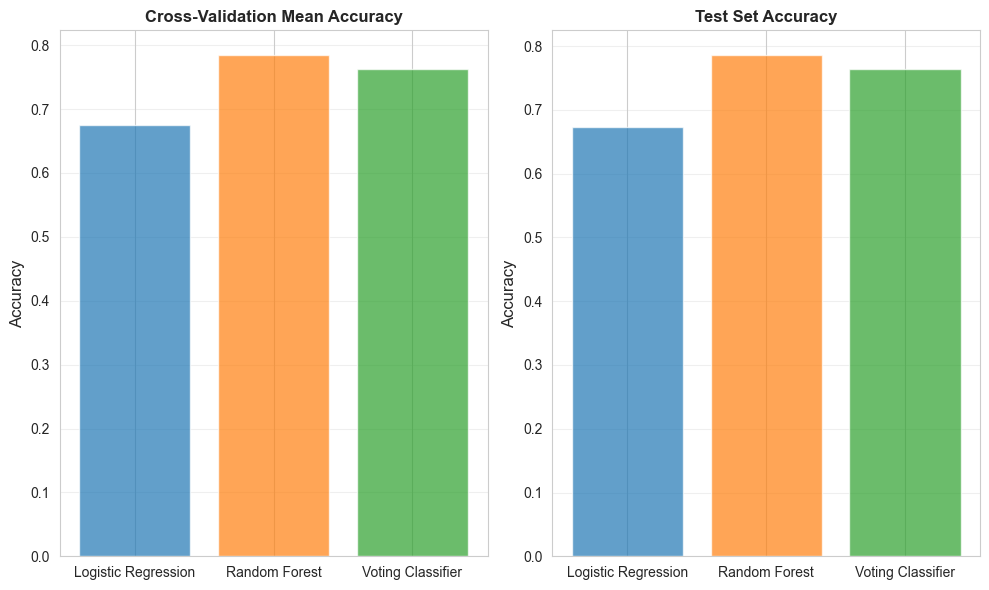

In [ ]:
# Model Comparison Bar Chart
from sklearn.metrics import accuracy_score

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

model_names = list(results.keys())
cv_means = [results[name]["cv_scores"].mean() for name in model_names]
cv_stds = [results[name]["cv_scores"].std() for name in model_names]

# CV Accuracy Comparison
axes[0].bar(
    model_names,
    cv_means,
    alpha=0.7,
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],
)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Cross-Validation Mean Accuracy", fontsize=12, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Test Set Accuracy
test_accuracies = [
    accuracy_score(y_test, results[name]["y_pred"]) for name in model_names
]
axes[1].bar(
    model_names, test_accuracies, alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c"]
)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Test Set Accuracy", fontsize=12, fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()


In [ ]:
print("MODEL PERFORMANCE SUMMARY")

for i, name in enumerate(model_names):
    print(
        f"Model: {name}. CV Mean Accuracy: {cv_means[i]:.4f}. Test Accuracy: {test_accuracies[i]:.4f}"
    )

MODEL PERFORMANCE SUMMARY
Model: Logistic Regression. CV Mean Accuracy: 0.6744. Test Accuracy: 0.6736
Model: Random Forest. CV Mean Accuracy: 0.7839. Test Accuracy: 0.7854
Model: Voting Classifier. CV Mean Accuracy: 0.7624. Test Accuracy: 0.7649


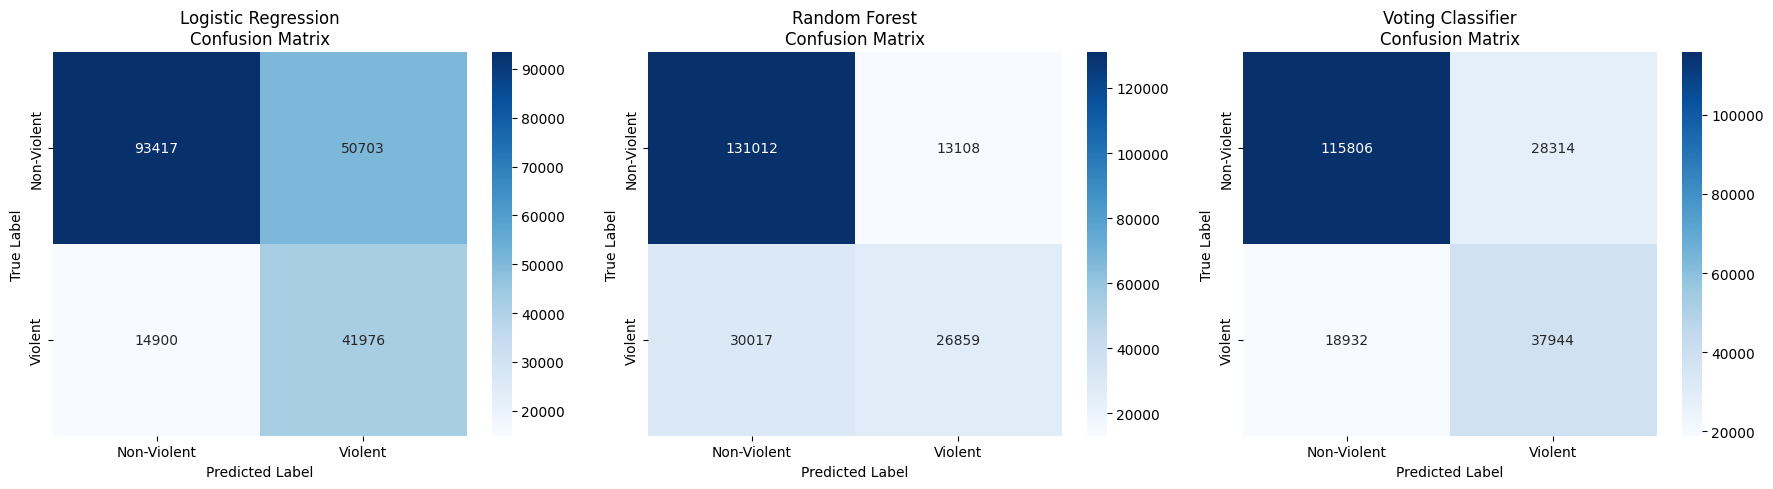

In [ ]:
# Visualization 2: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[idx],
        xticklabels=["Non-Violent", "Violent"],
        yticklabels=["Non-Violent", "Violent"],
    )
    axes[idx].set_title(f"{name}\nConfusion Matrix")
    axes[idx].set_ylabel("True Label")
    axes[idx].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

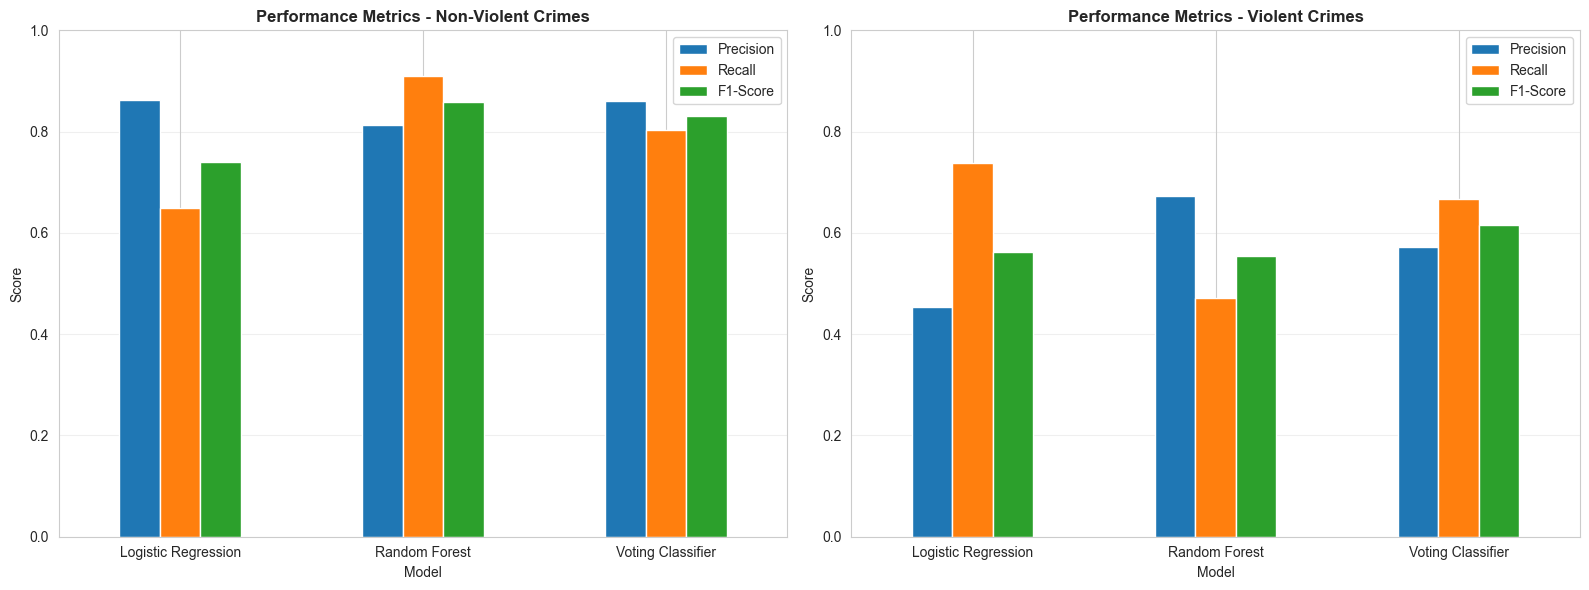


Detailed Metrics by Class:
              Model  Precision (Non-Violent)  Recall (Non-Violent)  F1 (Non-Violent)  Precision (Violent)  Recall (Violent)  F1 (Violent)
Logistic Regression                 0.862441              0.648189          0.740121             0.452918          0.738027      0.561345
      Random Forest                 0.813593              0.909048          0.858676             0.672029          0.472238      0.554692
  Voting Classifier                 0.859490              0.803539          0.830573             0.572670          0.667136      0.616304


In [ ]:
# Visualization 6: Model Performance by Class
from sklearn.metrics import f1_score, precision_score, recall_score

metrics_data = []
for name, result in results.items():
    metrics_data.append(
        {
            "Model": name,
            "Precision (Non-Violent)": precision_score(
                y_test, result["y_pred"], pos_label=0
            ),
            "Recall (Non-Violent)": recall_score(y_test, result["y_pred"], pos_label=0),
            "F1 (Non-Violent)": f1_score(y_test, result["y_pred"], pos_label=0),
            "Precision (Violent)": precision_score(
                y_test, result["y_pred"], pos_label=1
            ),
            "Recall (Violent)": recall_score(y_test, result["y_pred"], pos_label=1),
            "F1 (Violent)": f1_score(y_test, result["y_pred"], pos_label=1),
        }
    )

metrics_df = pd.DataFrame(metrics_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Non-Violent metrics
metrics_df.set_index("Model")[
    ["Precision (Non-Violent)", "Recall (Non-Violent)", "F1 (Non-Violent)"]
].plot(kind="bar", ax=axes[0], rot=0, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0].set_title(
    "Performance Metrics - Non-Violent Crimes", fontsize=12, fontweight="bold"
)
axes[0].set_ylabel("Score")
axes[0].set_ylim([0, 1.0])
axes[0].legend(["Precision", "Recall", "F1-Score"])
axes[0].grid(axis="y", alpha=0.3)

# Violent metrics
metrics_df.set_index("Model")[
    ["Precision (Violent)", "Recall (Violent)", "F1 (Violent)"]
].plot(kind="bar", ax=axes[1], rot=0, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_title(
    "Performance Metrics - Violent Crimes", fontsize=12, fontweight="bold"
)
axes[1].set_ylabel("Score")
axes[1].set_ylim([0, 1.0])
axes[1].legend(["Precision", "Recall", "F1-Score"])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDetailed Metrics by Class:")
print(metrics_df)